In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load the dataset
file_path = '/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
data = pd.read_csv(file_path)

In [6]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# checking datatypes
data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
# Convert 'TotalCharges' to numeric and drop missing values
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data_cleaned = data.dropna(subset=['TotalCharges'])

In [10]:
# checking datatypes
data.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [11]:
# Identifying categorical and numerical columns
categorical_cols = data_cleaned.select_dtypes(include=['object']).columns.drop(['customerID', 'Churn'])
numerical_cols = data_cleaned.select_dtypes(include=['int64', 'float64']).columns

In [12]:
# Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

In [13]:
# Applying the transformations
X = preprocessor.fit_transform(data_cleaned.drop(['customerID', 'Churn'], axis=1))
y = data_cleaned['Churn'].apply(lambda x: 1 if x == 'Yes' else 0).values

In [14]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [18]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_feature_importance = dt_model.feature_importances_.reshape(1, -1)

# Evaluate Decision Tree
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7275312855517634


In [19]:
# Train Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn_model = MLPClassifier(random_state=42, max_iter=1000, solver='adam', learning_rate_init=0.001)
nn_model.fit(X_train_scaled, y_train)

# Evaluate Neural Network
nn_predictions = nn_model.predict(X_test_scaled)
nn_accuracy = accuracy_score(y_test, nn_predictions)
print("Neural Network Accuracy:", nn_accuracy)

Neural Network Accuracy: 0.7565415244596132


In [20]:
# Extract features from neural network (last hidden layer activations)
nn_hidden_layer_output = nn_model.predict_proba(X_train_scaled)[:, 1].reshape(-1, 1)

In [23]:
# Concatenate DT feature importance & NN learned features
hybrid_features_train = np.hstack((X_train, nn_hidden_layer_output))

In [30]:
# Apply PCA for dimensionality reduction
pca = PCA(n_components=10)
hybrid_features_train = pca.fit_transform(hybrid_features_train)

# Train final model (Random Forest)
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(hybrid_features_train, y_train)

# Prepare test set
nn_hidden_layer_output_test = nn_model.predict_proba(X_test_scaled)[:, 1].reshape(-1, 1)
hybrid_features_test = np.hstack((X_test, nn_hidden_layer_output_test))
hybrid_features_test = pca.transform(hybrid_features_test)

# Evaluate final model
final_predictions = final_model.predict(hybrid_features_test)
final_accuracy = accuracy_score(y_test, final_predictions)

print("Final Hybrid Model Accuracy:", final_accuracy)

Final Hybrid Model Accuracy: 0.7815699658703071


In [33]:
# Confusion matrices
print("Confusion Matrix for Decision Tree Model:")
dt_cm = confusion_matrix(y_test, dt_predictions)
print(pd.DataFrame(dt_cm, index=['Actual No', 'Actual Yes'], columns=['Predicted No', 'Predicted Yes']))

print("Confusion Matrix for Neural Network Model:")
nn_cm = confusion_matrix(y_test, nn_predictions)
print(pd.DataFrame(nn_cm, index=['Actual No', 'Actual Yes'], columns=['Predicted No', 'Predicted Yes']))

print("Confusion Matrix for Hybrid Model:")
final_cm = confusion_matrix(y_test, final_predictions)
print(pd.DataFrame(final_cm, index=['Actual No', 'Actual Yes'], columns=['Predicted No', 'Predicted Yes']))

Confusion Matrix for Decision Tree Model:
            Predicted No  Predicted Yes
Actual No           1040            260
Actual Yes           219            239
Confusion Matrix for Neural Network Model:
            Predicted No  Predicted Yes
Actual No           1100            200
Actual Yes           228            230
Confusion Matrix for Hybrid Model:
            Predicted No  Predicted Yes
Actual No           1165            135
Actual Yes           249            209


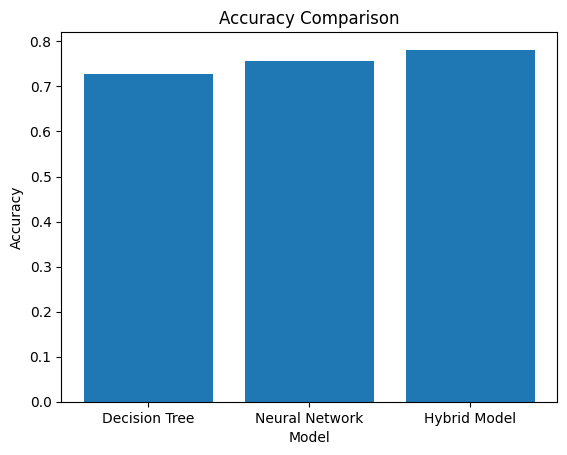

In [34]:
# Accuracy comparison chart
plt.bar(['Decision Tree', 'Neural Network', 'Hybrid Model'], [dt_accuracy, nn_accuracy, final_accuracy])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.show()